### import

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc("font",family='Kai')
plt.rcParams['axes.unicode_minus'] =False
from pyqpanda import *
from sklearn import linear_model
from scipy.integrate import solve_ivp
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget

### Lorenz63

[[0.55001888 0.48059211 0.51014173]
 [0.54277692 0.48160521 0.49472688]
 [0.53627966 0.48260756 0.47977415]
 ...
 [0.57852981 0.60400324 0.17114616]
 [0.58353837 0.61118628 0.16695064]
 [0.58898373 0.6189629  0.16327176]]


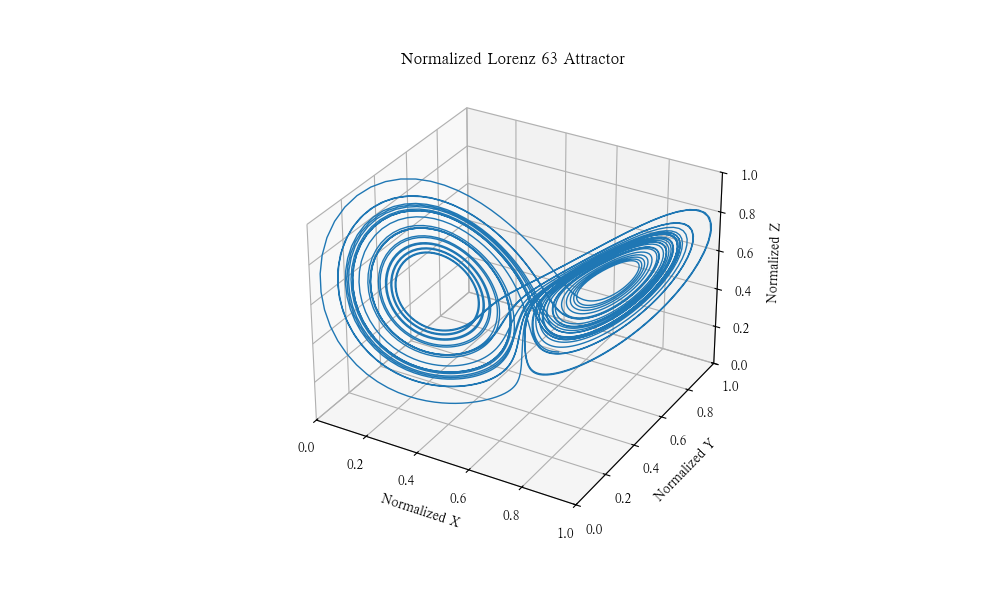

In [10]:
def lorenz63(x0):

    def RK45(x, func, h):
        """四阶龙格-库塔积分器"""
        K1 = func(x)
        K2 = func(x + h/2*K1)
        K3 = func(x + h/2*K2)
        K4 = func(x + h*K3)
        return x + h/6*(K1 + 2*K2 + 2*K3 + K4)

    def L63_rhs(x, sigma=10.0, rho=28.0, beta=8/3):
        """定义Lorenz 63微分方程"""
        dx = np.zeros(3)
        dx[0] = sigma * (x[1] - x[0])
        dx[1] = rho*x[0] - x[1] - x[0]*x[2]
        dx[2] = x[0]*x[1] - beta*x[2]
        return dx

    def integrate_lorenz63(x0, num_steps=4000, dt=0.01*0.9056):
        """执行数值积分"""
        trajectory = np.zeros((num_steps, 3))
        trajectory[0] = x0
        for t in range(1, num_steps):
            trajectory[t] = RK45(trajectory[t-1], L63_rhs, dt)
        return trajectory

    def normalize_trajectory(trajectory):
        """将轨迹归一化到[0, 1]范围"""
        # 计算每个坐标轴的极值
        mins = np.min(trajectory, axis=0)
        maxs = np.max(trajectory, axis=0)
        
        # 线性归一化公式：new = (original - min)/(max - min)
        normalized =(trajectory - mins) / (maxs - mins)
        return normalized

    traj = integrate_lorenz63(x0)
    traj_normalized = normalize_trajectory(traj)
    return traj_normalized

x0 = np.array([1.508870, -1.531271, 25.46091])  # 混沌初值
traj_normalized = lorenz63(x0)  
print(traj_normalized)
# 绘制归一化后的轨迹
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(traj_normalized[:,0], traj_normalized[:,1], traj_normalized[:,2],lw=1)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])
ax.set_xlabel("Normalized X")
ax.set_ylabel("Normalized Y")
ax.set_zlabel("Normalized Z")
plt.title("Normalized Lorenz 63 Attractor")
plt.show()


### 9-qubit machine

In [11]:
def train_ridge_model(washout,nstop_train, alpha, loading_dataX, loading_datay):
    """训练模型"""
    # 准备训练数据
    X_train = loading_dataX[washout:nstop_train]
    y_train = loading_datay[washout:nstop_train]
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    # 训练模型
    ridge = Ridge(alpha)
    ridge.fit(X_train, y_train)
    return ridge, washout, nstop_train

def predict_next_state(method, loading_dataX, loading_datay):
    predictions = []
    for i in range(len(loading_datay)):  
        features = loading_dataX[i]  # 使用已有的量子输出
        all_state_pred = method.predict([features])  # 使用传入的method对象
        predictions.append(all_state_pred[0])
    predictions = np.array(predictions)
    return predictions

def all_probabilities(n_qubits, n_cbits,varepsilon,seed):

    def update_params():
        params = [0] * (2**n_qubits)
        if i > 0:
            # 使用上一次的sorted_values更新参数
            for j in range(len(sorted_values)):
                params[j] = sorted_values[j]*4*np.pi
        return params

    def create_quantum_circuit():
        """创建并返回量子线路"""
        qvm = CPUQVM()
        qvm.init_qvm()
        
        qubits = qvm.qAlloc_many(n_qubits)
        cbits = qvm.cAlloc_many(n_qubits)
        def module(Ry):
            circuit = QCircuit()
            Ry_index = 0
            ccc = (len(Ry) + n_qubits - 1) // n_qubits
            for layer in range(ccc):
                for qubit in range(n_qubits):
                    if Ry_index < len(Ry):
                        circuit << RY(qubits[qubit], Ry[Ry_index])
                        Ry_index += 1
                        if qubit < n_qubits - 1:
                            circuit << CNOT(qubits[qubit], qubits[qubit+1])
            return circuit
        # 构建量子程序
        prog = QProg()
        circuit = QCircuit()
        circuit << module(Ry=params)
        circuit << module(Ry=traj_norm)
        circuit << module(Ry=beta_gate)
        prog << circuit
        
        result = qvm.prob_run_dict(prog, qubits, -1)
        value_list = list(result.values())
        return value_list

    def nolinearize():
        """非线性化处理"""
        if i > 0:
            raw_sorted_values = [0] * len(sorted_values)
            for j in range(len(sorted_values)):
                raw_sorted_values[j] = round(varepsilon * value_list[j] + (1 - varepsilon) * sorted_values[j],5)
        else:
            raw_sorted_values = value_list.copy()
        return raw_sorted_values

    quantum_outputs = [[0]*(2**n_qubits)]
    for i in range(len(traj_normalized)):
        params = update_params()
        traj_norm = 4*np.pi*traj_normalized[i]
        np.random.seed (seed) 
        beta_gate = np.random.uniform (0,2*np.pi,n_qubits)
        value_list = create_quantum_circuit()
        sorted_values = nolinearize()
        quantum_outputs.append(sorted_values)
    return quantum_outputs

washout = 50
nstop_train = 2000
quantum_outputs = all_probabilities(n_qubits=9, n_cbits=9,varepsilon=0.05,seed=19)
ridge, washout, nstop_train= train_ridge_model(washout=50, nstop_train=2000, alpha=0, loading_dataX=quantum_outputs, loading_datay=traj_normalized)
predictions = predict_next_state(method=ridge, loading_dataX=quantum_outputs, loading_datay=traj_normalized)
mse = mean_squared_error(traj_normalized[nstop_train+1:], predictions[nstop_train:-1])#检查过，引用函数与文献一致
print(predictions)
print(f"测试集MSE: {mse}")


[[-2.01953515 -1.56563861 -2.06299522]
 [ 2.84775589  1.01730604  0.19045242]
 [ 2.69411266  0.93860651  0.06513077]
 ...
 [ 0.57012734  0.59745337  0.15941828]
 [ 0.57599705  0.60411348  0.15591966]
 [ 0.58198906  0.61237786  0.15013324]]
测试集MSE: 0.006778619172617487


### 可视化模块

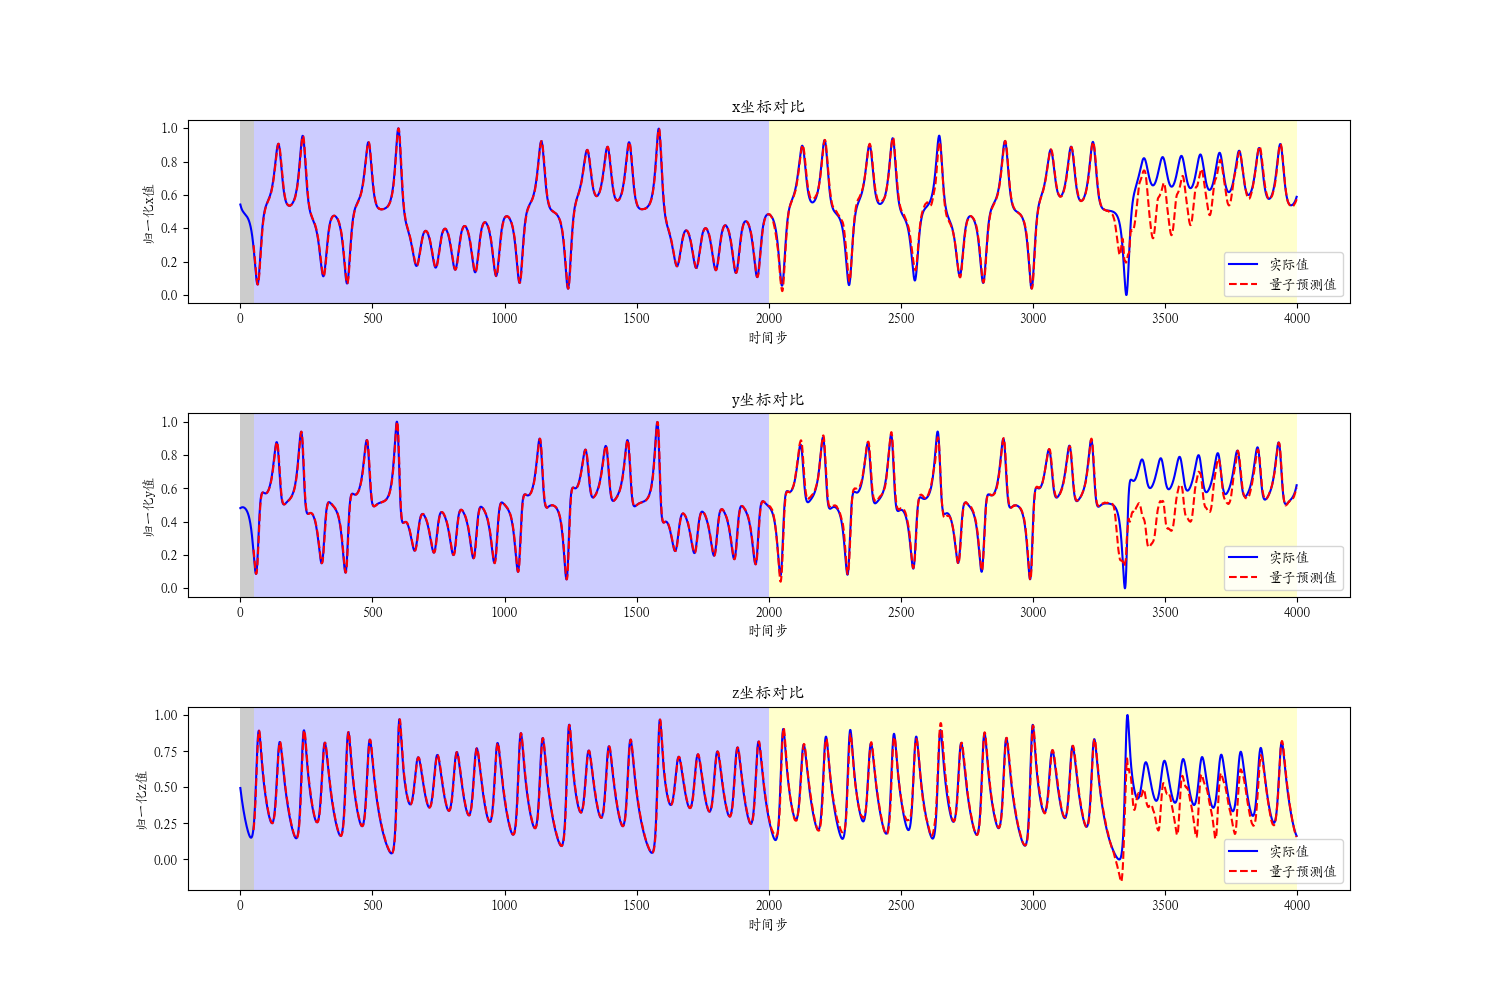

In [12]:
def plot_normalized_traj(traj_normalized, title="Normalized Trajectory"):
    """
    绘制归一化后的轨迹，根据数据维度自动选择 1D、2D 或 3D 绘图。

    :param traj_normalized: 归一化后的轨迹数据，为 numpy 数组
    :param title: 图的标题
    """
    dim = traj_normalized.shape[1]  # 获取数据的维度

    if dim == 1:
        # 1D 绘图
        fig = plt.figure(figsize=(10, 6))
        plt.plot(traj_normalized[:, 0], lw=1)
        plt.xlabel("Index")
        plt.ylabel("Normalized Value")
        plt.title(title)
    elif dim == 2:
        # 2D 绘图
        fig = plt.figure(figsize=(10, 6))
        plt.plot(traj_normalized[:, 0], traj_normalized[:, 1], lw=1)
        plt.xlim([0, 1])
        plt.ylim([0, 1])
        plt.xlabel("Normalized X")
        plt.ylabel("Normalized Y")
        plt.title(title)
    elif dim == 3:
        # 3D 绘图
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot(traj_normalized[:, 0], traj_normalized[:, 1], traj_normalized[:, 2], lw=1)
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        ax.set_zlim([0, 1])
        ax.set_xlabel("Normalized X")
        ax.set_ylabel("Normalized Y")
        ax.set_zlabel("Normalized Z")
        plt.title(title)
    else:
        print(f"不支持绘制 {dim} 维的轨迹图。仅支持 1D、2D 或 3D 绘图。")
        return

    plt.show()

def plot_comparison(dimensions=('x', 'y', 'z'), plot_3d=True, plot_washout = False):
    """
    绘制 2D 对比图和 3D 轨迹对比图

    参数:
    washout (int): 清洗期的长度
    nstop_train (int): 特定时间步
    traj_normalized (np.ndarray): 实际轨迹的归一化数据，二维数组
    predictions (np.ndarray): 量子预测的轨迹数据，二维数组
    dimensions (tuple): 要绘制的维度，默认为 ('x', 'y', 'z')
    plot_3d (bool): 是否绘制 3D 轨迹对比图，默认为 True
    """
    num_dims = len(dimensions)
    if num_dims > 0:
        # 创建一个包含多个子图的图形窗口
        fig_2d, axes = plt.subplots(num_dims, 1, figsize=(15, 10))
        if num_dims == 1:
            axes = [axes]

        def onselect(xmin, xmax):
            for ax in axes:
                ax.set_xlim(xmin, xmax)
            fig_2d.canvas.draw_idle()

        for i, dim in enumerate(dimensions):
            # 计算子图的位置
            ax = axes[i]
            if plot_washout :
                # 绘制实际值曲线
                ax.plot(traj_normalized[1:, i], 'b-', label='实际值')
                # 绘制量子预测值曲线
                ax.plot(predictions[:-1, i], 'r--', label='量子预测值')
                # 设置子图的标题
                ax.set_title(f'{dim}坐标对比')
                # 设置 x 轴的标签
                ax.set_xlabel('时间步')
                # 设置 y 轴的标签
                ax.set_ylabel(f'归一化{dim}值')
                # 显示图例
                ax.legend()
            else:
                predictions[0:washout, i] = np.nan
                # 绘制实际值曲线
                ax.plot(traj_normalized[1:, i], 'b-', label='实际值')
                # 绘制量子预测值曲线
                ax.plot(predictions[:-1, i], 'r--', label='量子预测值')
                # 设置子图的标题
                ax.set_title(f'{dim}坐标对比')
                # 设置 x 轴的标签
                ax.set_xlabel('时间步')
                # 设置 y 轴的标签
                ax.set_ylabel(f'归一化{dim}值')
                # 显示图例
                ax.legend()

            #
            ax.axvspan(0, washout, facecolor='black', alpha=0.2)
            # 添加蓝色背景
            ax.axvspan(washout, nstop_train, facecolor='blue', alpha=0.2)
            # 添加黄色背景
            ax.axvspan(nstop_train, len(traj_normalized), facecolor='yellow', alpha=0.2)

        # 调整子图之间的垂直间距，这里设置为 0.6，可以根据需要调整
        plt.subplots_adjust(hspace=0.6)

        # 创建 SpanSelector
        #span = SpanSelector(axes[0], onselect, 'horizontal', useblit=True,
        #                    rectprops=dict(alpha=0.5, facecolor='red'))

        #plt.show()

    if plot_3d and num_dims >= 3:
        # 创建一个 3D 图形窗口
        fig_3d = plt.figure(figsize=(12, 10))
        ax = fig_3d.add_subplot(111, projection='3d')
        # 绘制实际轨迹
        ax.plot(traj_normalized[washout:-1, 0], traj_normalized[washout:-1, 1], traj_normalized[washout:-1, 2], 'b-', label='实际轨迹')
        # 绘制预测轨迹
        ax.plot(predictions[washout + 1:, 0], predictions[washout + 1:, 1], predictions[washout + 1:, 2], 'r--', label='量子预测轨迹')
        # 设置 3D 图的标题
        ax.set_title('Lorenz系统轨迹对比')
        # 设置 x 轴的标签
        ax.set_xlabel('X轴')
        # 设置 y 轴的标签
        ax.set_ylabel('Y轴')
        # 设置 z 轴的标签
        ax.set_zlabel('Z轴')
        # 显示图例
        ax.legend()
        plt.show()


plot_comparison(dimensions=('x', 'y', 'z'), plot_3d=False, plot_washout = False)